# Day 3 — Backtesting Engine

**Goal**: Run the signal-based strategy against 6 years of OHLCV data and produce a full performance report.

| Parameter | Value |
|-----------|-------|
| Initial capital | $100,000 |
| Commission | 0.1% per trade |
| Signal lag | 1 day (no lookahead bias) |
| Benchmark | Equal-weight buy-and-hold |
| Universe | 10 large-cap US stocks |

**Key metrics tracked**: Total Return, CAGR, Sharpe Ratio, Sortino, Calmar, Max Drawdown, Win Rate, Profit Factor

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'grid.linewidth': 0.5,
    'figure.dpi': 120,
})

print('Environment ready ✓')

Environment ready ✓


## 1. Load Data + Signals + Run Backtest

In [2]:
from src.data.loader import DataLoader
from src.signals.generator import SignalGenerator
from src.backtest.engine import BacktestEngine

# Load cached data
loader  = DataLoader()
ohlcv   = loader.load(force_download=False)

# Generate signals
sg      = SignalGenerator(ohlcv)
signals = sg.generate_all()

# Run backtest
engine  = BacktestEngine(initial_capital=100_000, commission=0.001)
results = engine.run_portfolio(signals)

print('\nBacktest complete!')
print(f'Portfolio final value: ${results["portfolio_equity"].iloc[-1]:,.0f}')

23:20:09 | INFO | DataLoader | Loading data for 10 tickers | 2018-01-01 → 2024-12-31


23:20:09 | INFO | DataLoader |   AAPL   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AAPL.csv


23:20:09 | INFO | DataLoader |   MSFT   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_MSFT.csv


23:20:09 | INFO | DataLoader |   GOOGL  — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_GOOGL.csv


23:20:09 | INFO | DataLoader |   AMZN   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AMZN.csv


...

23:20:09 | INFO | BacktestEngine |   JNJ    | Return: -0.2% | Sharpe: 0.04 | MaxDD: 18.0% | Trades: 17


23:20:09 | INFO | BacktestEngine |   TSLA   | Return: +10.5% | Sharpe: 0.29 | MaxDD: 8.2% | Trades: 13


23:20:09 | INFO | BacktestEngine |   NVDA   | Return: -17.1% | Sharpe: -0.33 | MaxDD: 30.8% | Trades: 15


23:20:09 | INFO | BacktestEngine | 
PORTFOLIO | Return: +10.1% | Sharpe: 0.45 | MaxDD: 6.9%



Backtest complete!
Portfolio final value: $110,121


## 2. Portfolio Equity Curve vs Buy-and-Hold

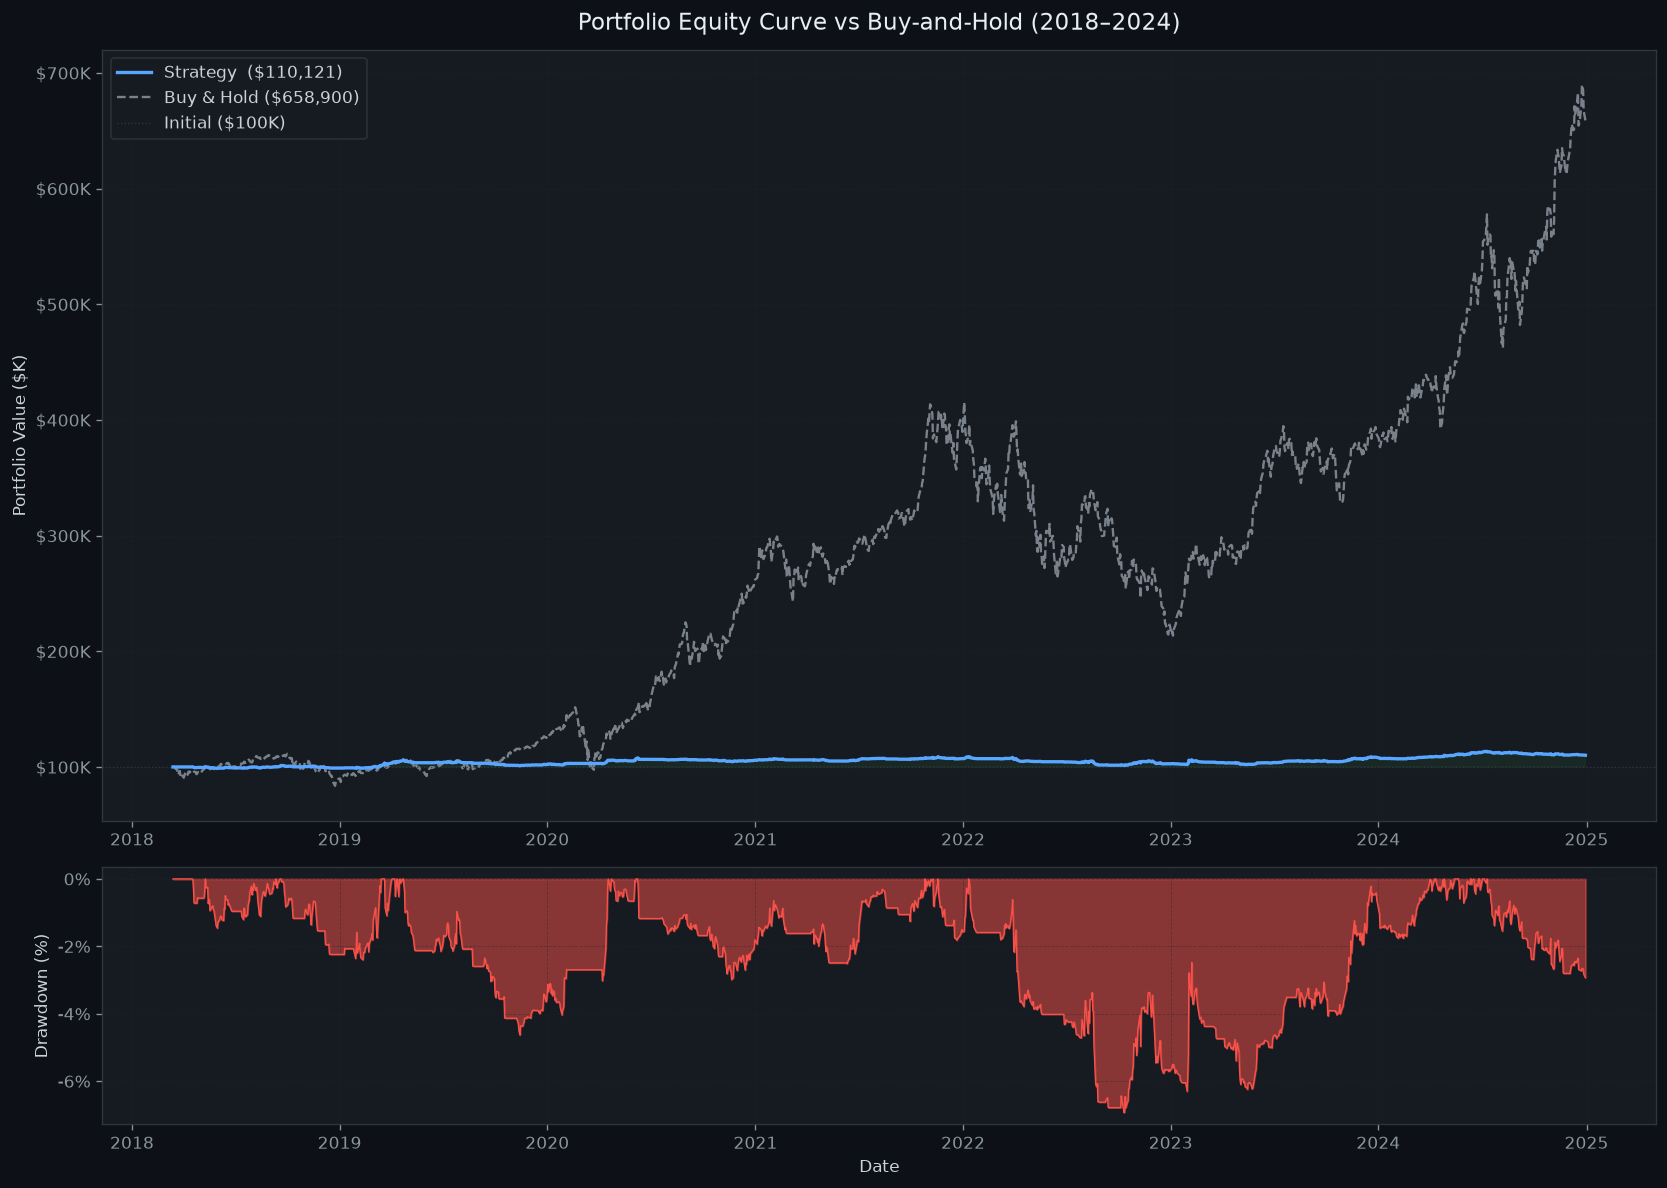

Saved → reports/day3_equity_curve.png


In [3]:
port_eq = results['portfolio_equity']
bh_eq   = results['benchmark_equity']

fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.08)

# ── Equity curve ─────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(port_eq.index, port_eq / 1000, color='#58a6ff', lw=2.0,
         label=f'Strategy  (${port_eq.iloc[-1]:,.0f})', zorder=3)
ax1.plot(bh_eq.index,   bh_eq / 1000,   color='#8b949e', lw=1.4,
         label=f'Buy & Hold (${bh_eq.iloc[-1]:,.0f})', ls='--', alpha=0.85)
ax1.axhline(100, color='#30363d', lw=0.8, ls=':', label='Initial ($100K)')
ax1.fill_between(port_eq.index, port_eq / 1000, 100,
                  where=(port_eq / 1000 >= 100), alpha=0.08, color='#3fb950')
ax1.fill_between(port_eq.index, port_eq / 1000, 100,
                  where=(port_eq / 1000 < 100),  alpha=0.08, color='#f85149')

ax1.set_title('Portfolio Equity Curve vs Buy-and-Hold (2018–2024)',
               fontsize=14, color='#e6edf3', pad=12)
ax1.set_ylabel('Portfolio Value ($K)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax1.legend(fontsize=10, loc='upper left',
            facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax1.grid(True, alpha=0.4)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── Drawdown ──────────────────────────────────────────────────────────────
from src.utils.metrics import compute_drawdown_series
dd = compute_drawdown_series(port_eq) * 100

ax2 = axes[1]
ax2.fill_between(dd.index, dd, 0, color='#f85149', alpha=0.5, label='Drawdown')
ax2.plot(dd.index, dd, color='#f85149', lw=0.8)
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig('../reports/day3_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day3_equity_curve.png')

## 3. Performance Metrics Table

In [4]:
key_cols = [
    'Total Return (%)', 'CAGR (%)', 'Sharpe Ratio', 'Sortino Ratio',
    'Max Drawdown (%)', 'Ann. Volatility (%)', 'Num Trades', 'Win Rate (%)', 'Profit Factor'
]

# Only keep columns that exist
available_cols = [c for c in key_cols if c in results['metrics_table'].columns]
table = results['metrics_table'][available_cols].copy()

print('=== Strategy vs Benchmark — Performance Metrics ===')
display(table)

# Highlight key portfolio metrics
pm = results['portfolio_metrics']
print(f"\n{'='*50}")
print(f"  PORTFOLIO SUMMARY")
print(f"{'='*50}")
print(f"  Total Return  : {pm['Total Return (%)']:+.2f}%")
print(f"  CAGR          : {pm['CAGR (%)']:+.2f}%")
print(f"  Sharpe Ratio  : {pm['Sharpe Ratio']:.3f}")
print(f"  Sortino Ratio : {pm['Sortino Ratio']:.3f}")
print(f"  Max Drawdown  : {pm['Max Drawdown (%)']:.2f}%")
print(f"  Ann. Volatility: {pm['Ann. Volatility (%)']:.2f}%")
print(f"{'='*50}")

=== Strategy vs Benchmark — Performance Metrics ===


,Total Return (%),CAGR (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Ann. Volatility (%),Num Trades,Win Rate (%),Profit Factor
AAPL,8.79,1.25,0.215,0.109,13.14,6.86,14.0,35.7,1.625
MSFT,-6.03,-0.91,-0.076,-0.029,22.70,7.91,15.0,33.3,0.971
GOOGL,32.38,4.22,0.462,0.250,11.98,10.02,12.0,50.0,3.970
AMZN,56.38,6.81,0.675,0.483,12.21,10.57,19.0,36.8,3.043
JPM,-15.37,-2.43,-0.271,-0.141,28.82,7.91,15.0,26.7,0.693
BAC,-4.93,-0.74,-0.033,-0.019,22.64,9.35,18.0,22.2,1.048
XOM,36.80,4.72,0.498,0.349,14.46,10.34,18.0,55.6,2.518
JNJ,-0.24,-0.04,0.039,0.028,17.98,8.51,17.0,41.2,1.166
TSLA,10.47,1.48,0.294,0.066,8.23,5.51,13.0,53.8,1.946
NVDA,-17.06,-2.72,-0.327,-0.094,30.80,7.54,15.0,46.7,0.508



  PORTFOLIO SUMMARY
  Total Return  : +10.12%
  CAGR          : +1.43%
  Sharpe Ratio  : 0.446
  Sortino Ratio : 0.542
  Max Drawdown  : 6.93%
  Ann. Volatility: 3.32%


## 4. Per-Ticker Performance Heatmap

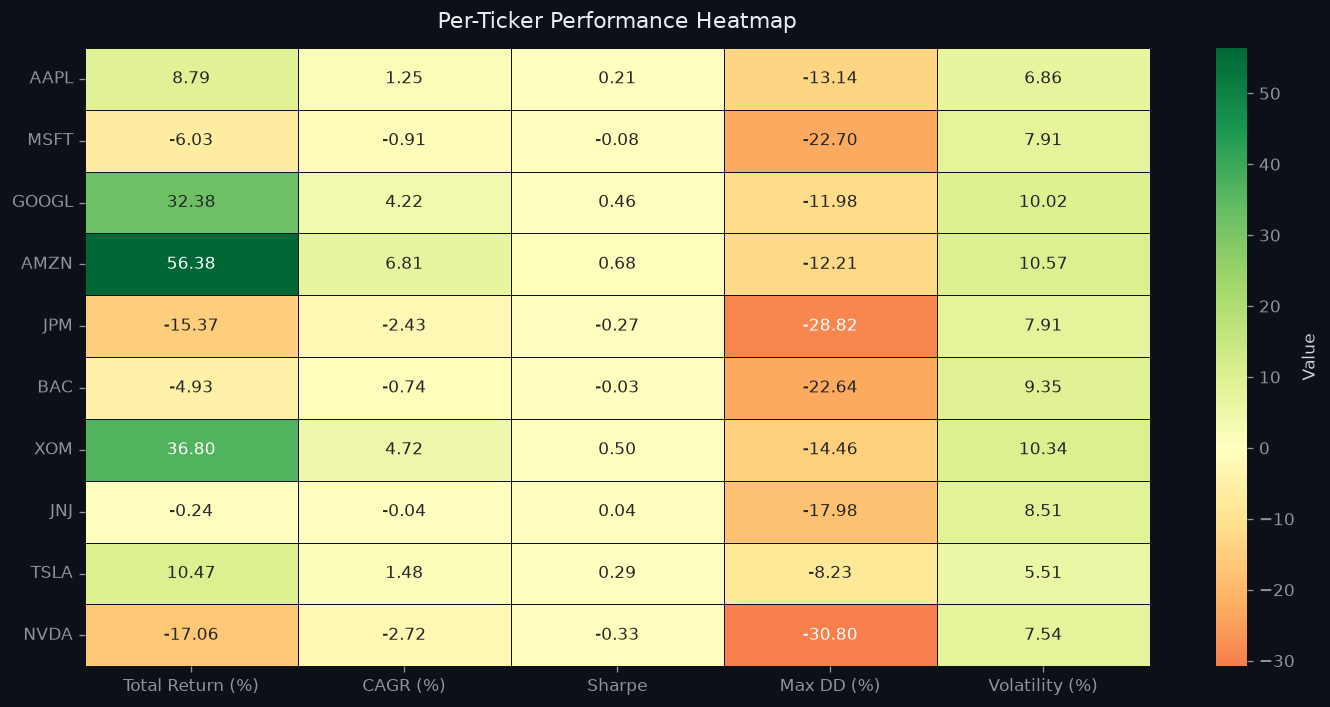

Saved → reports/day3_ticker_heatmap.png


In [5]:
ticker_rows = {}
for ticker, result in results['ticker_results'].items():
    m = result['metrics']
    ticker_rows[ticker] = {
        'Total Return (%)': m['Total Return (%)'],
        'CAGR (%)':         m['CAGR (%)'],
        'Sharpe':           m['Sharpe Ratio'],
        'Max DD (%)':       -m['Max Drawdown (%)'],   # negative for visual clarity
        'Volatility (%)':   m['Ann. Volatility (%)'],
    }

ticker_df = pd.DataFrame(ticker_rows).T

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    ticker_df.astype(float), annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='#0d1117',
    annot_kws={'size': 10}, ax=ax,
    cbar_kws={'label': 'Value'}
)
ax.set_title('Per-Ticker Performance Heatmap', fontsize=13, color='#e6edf3', pad=12)
plt.tight_layout()
fig.savefig('../reports/day3_ticker_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day3_ticker_heatmap.png')

## 5. Individual Equity Curves — All Tickers

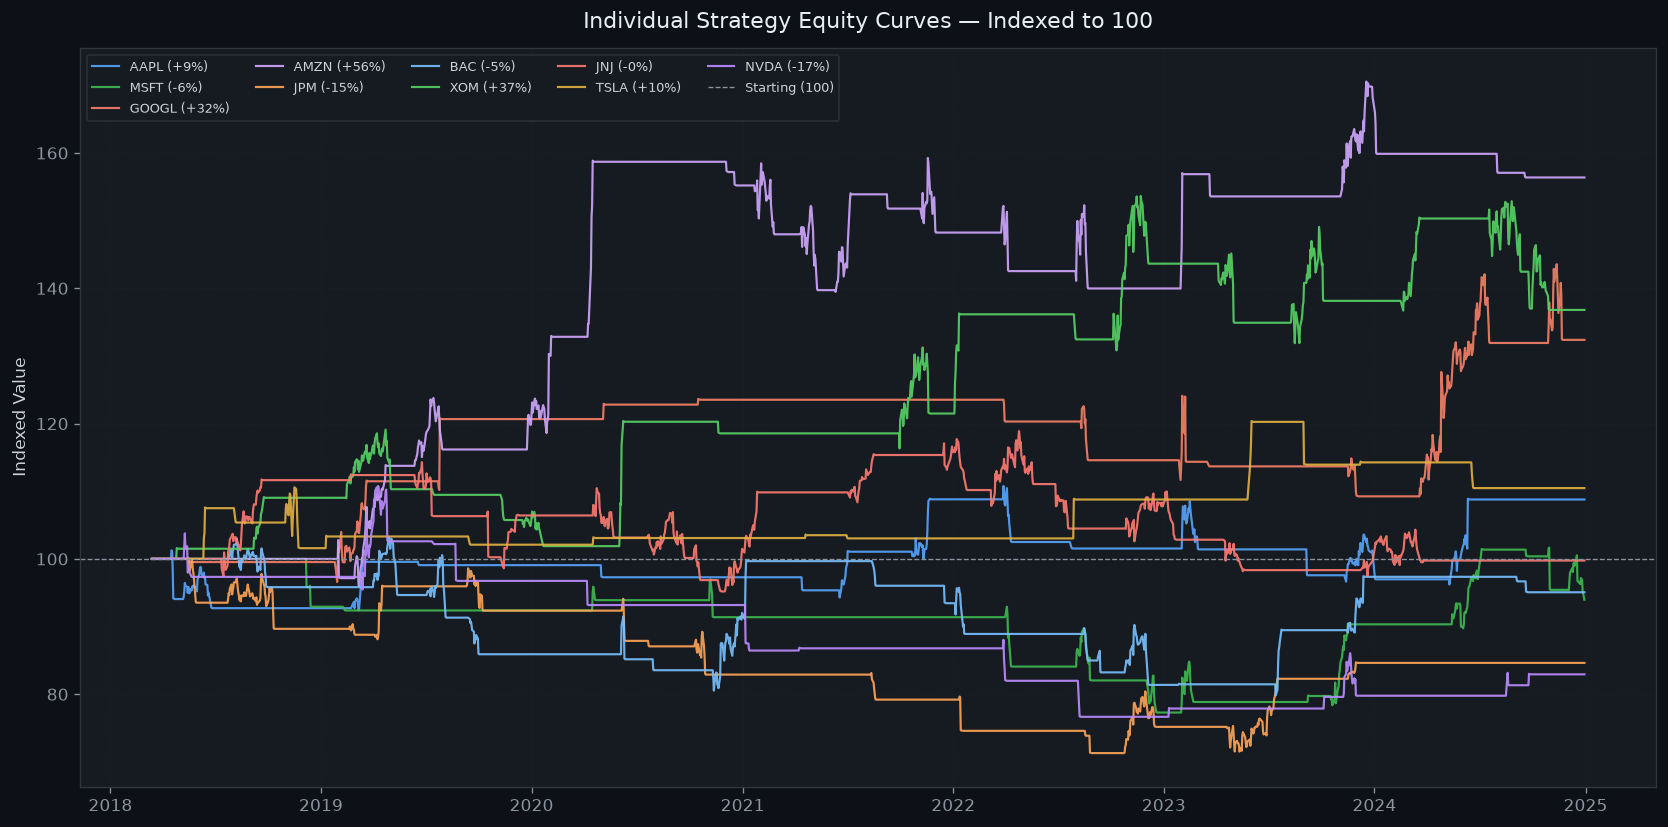

Saved → reports/day3_individual_curves.png


In [6]:
ACCENT = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657',
          '#79c0ff','#56d364','#ff7b72','#e3b341','#bc8cff']

equity_df = results['equity_df']

fig, ax = plt.subplots(figsize=(14, 7))
for i, ticker in enumerate(equity_df.columns):
    norm = equity_df[ticker] / equity_df[ticker].iloc[0] * 100
    total_ret = results['ticker_results'][ticker]['metrics']['Total Return (%)']
    ax.plot(norm.index, norm, color=ACCENT[i], lw=1.3,
            label=f'{ticker} ({total_ret:+.0f}%)', alpha=0.9)

ax.axhline(100, color='#8b949e', lw=0.8, ls='--', label='Starting (100)')
ax.set_title('Individual Strategy Equity Curves — Indexed to 100',
              fontsize=13, color='#e6edf3', pad=12)
ax.set_ylabel('Indexed Value')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(ncol=5, fontsize=8, loc='upper left',
           facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.4)
plt.tight_layout()
fig.savefig('../reports/day3_individual_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day3_individual_curves.png')

## 6. Monthly Returns Heatmap

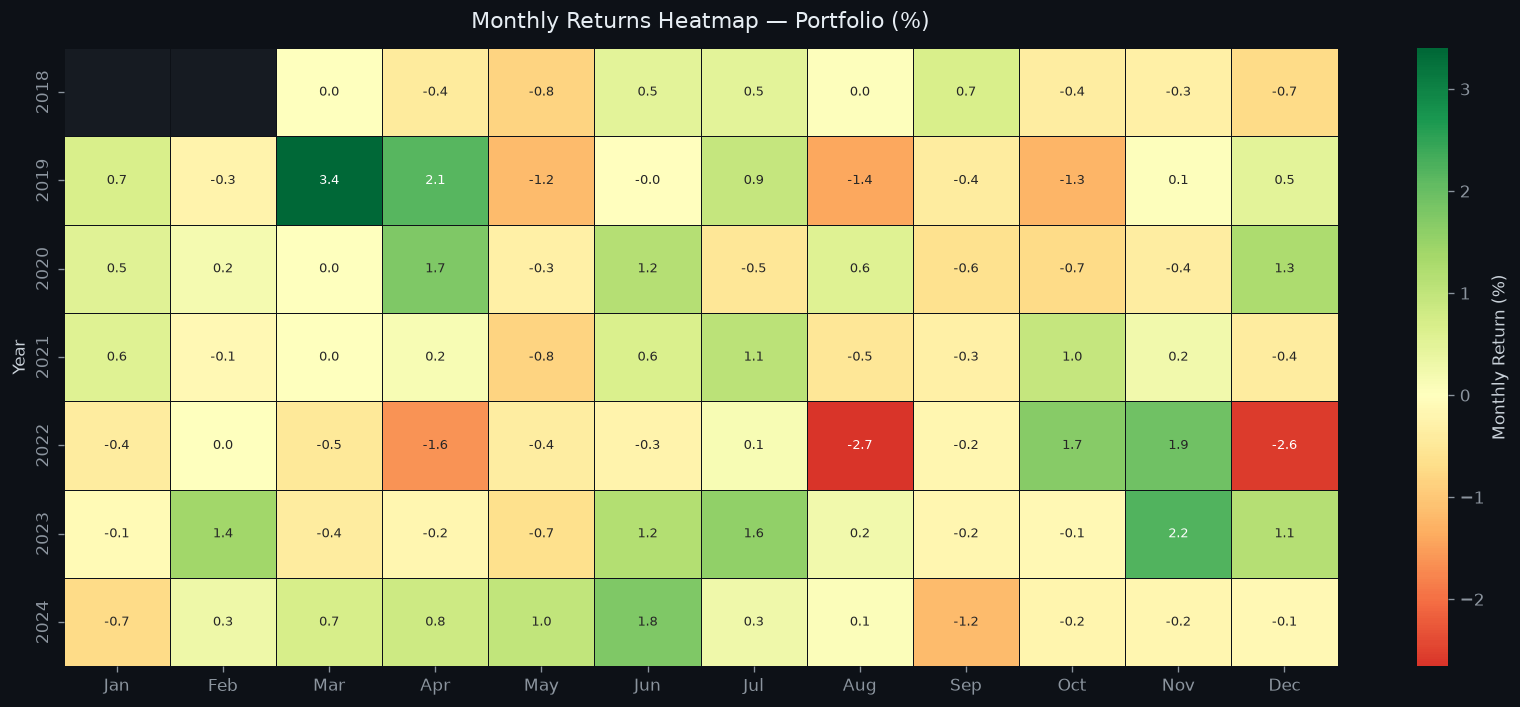

Saved → reports/day3_monthly_returns.png


In [7]:
port_returns = results['portfolio_returns']
monthly_ret  = port_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1) * 100
monthly_df   = monthly_ret.to_frame('Return')
monthly_df['Year']  = monthly_df.index.year
monthly_df['Month'] = monthly_df.index.strftime('%b')

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot  = monthly_df.pivot_table(index='Year', columns='Month', values='Return')
pivot  = pivot.reindex(columns=MONTHS)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='#0d1117',
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'label': 'Monthly Return (%)'}
)
ax.set_title('Monthly Returns Heatmap — Portfolio (%)', fontsize=13, color='#e6edf3', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Year')
plt.tight_layout()
fig.savefig('../reports/day3_monthly_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day3_monthly_returns.png')

## 7. Return Distribution

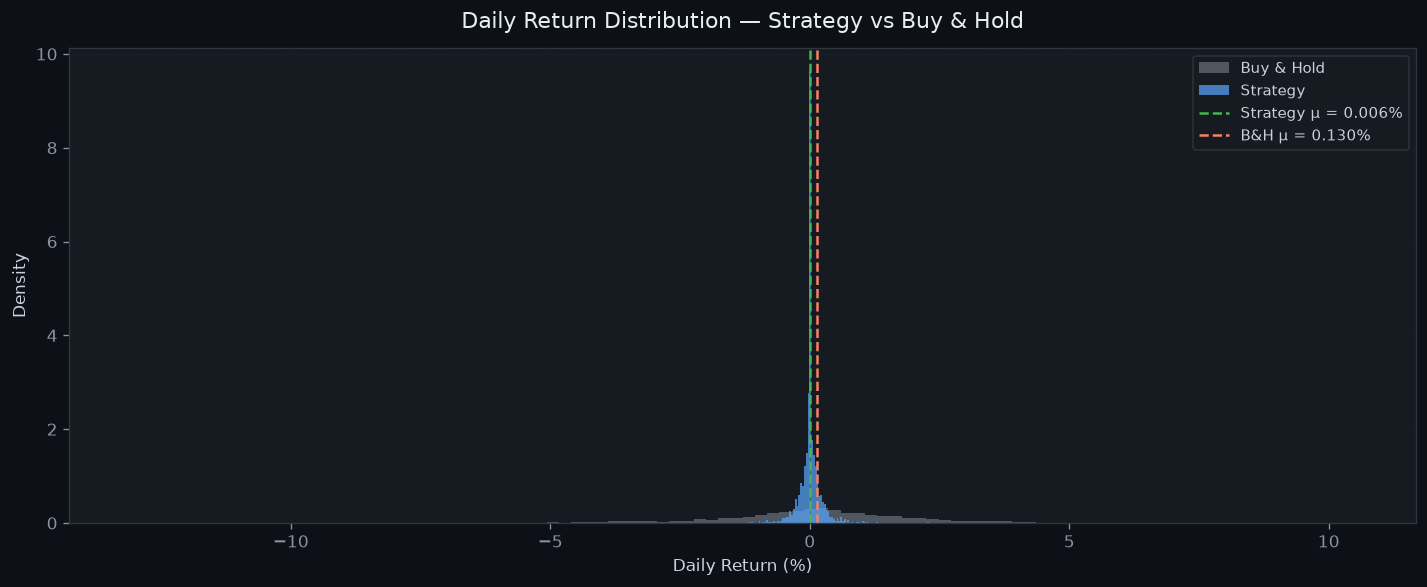

Saved → reports/day3_return_distribution.png


In [8]:
r = results['portfolio_returns'] * 100
bh_r = results['benchmark_equity'].pct_change().dropna() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(bh_r, bins=100, color='#8b949e', alpha=0.5, label='Buy & Hold', density=True)
ax.hist(r,    bins=100, color='#58a6ff', alpha=0.7, label='Strategy',   density=True)

ax.axvline(r.mean(),   color='#3fb950', lw=1.5, ls='--', label=f'Strategy μ = {r.mean():.3f}%')
ax.axvline(bh_r.mean(),color='#f78166', lw=1.5, ls='--', label=f'B&H μ = {bh_r.mean():.3f}%')

ax.set_title('Daily Return Distribution — Strategy vs Buy & Hold',
              fontsize=13, color='#e6edf3', pad=12)
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Density')
ax.legend(fontsize=9, facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.4)
plt.tight_layout()
fig.savefig('../reports/day3_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day3_return_distribution.png')

## 8. QuantStats Full Tear Sheet

In [9]:
import quantstats as qs

port_ret = results['portfolio_returns']
bh_ret   = results['benchmark_equity'].pct_change().dropna()

# Align indices
port_ret = port_ret[port_ret.index.isin(bh_ret.index)]
bh_ret   = bh_ret[bh_ret.index.isin(port_ret.index)]

# Save HTML tear sheet
qs.reports.html(
    port_ret,
    benchmark=bh_ret,
    output='../reports/day3_tearsheet.html',
    title='Algo Trading System — Strategy vs Buy & Hold',
)
print('Tear sheet saved → reports/day3_tearsheet.html')
print('Open this file in your browser for the full report.')

# Quick metrics printout
print('\n=== QuantStats Key Metrics ===')
print(f'Sharpe  : {qs.stats.sharpe(port_ret):.3f}')
print(f'Sortino : {qs.stats.sortino(port_ret):.3f}')
print(f'Max DD  : {qs.stats.max_drawdown(port_ret)*100:.2f}%')
print(f'CAGR    : {qs.stats.cagr(port_ret)*100:.2f}%')
print(f'Calmar  : {qs.stats.calmar(port_ret):.3f}')

Tear sheet saved → reports/day3_tearsheet.html
Open this file in your browser for the full report.

=== QuantStats Key Metrics ===
Sharpe  : 0.447
Sortino : 0.673
Max DD  : -7.19%
CAGR    : 1.44%
Calmar  : 0.200


## ✅ Day 3 Complete

| Deliverable | Status |
|-------------|--------|
| `src/backtest/engine.py` — BacktestEngine | ✅ |
| `src/utils/metrics.py` — metrics functions | ✅ |
| No-lookahead-bias (signal shift by 1 day) | ✅ |
| Transaction costs (0.1%) applied | ✅ |
| Portfolio equity curve vs buy-and-hold | ✅ |
| Per-ticker performance heatmap | ✅ |
| Monthly returns heatmap | ✅ |
| Return distribution chart | ✅ |
| QuantStats HTML tear sheet | ✅ |

**Next**: Day 4 — Fama-French Factor Attribution → `notebooks/day4_factor_attribution.ipynb`